This notebook reproduces Figure A5 in "Humidity’s role in population heat-health risk" by Kong et al.

In [12]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [13]:
# read in mean absolute prediction error for GHSI
mae=xr.open_dataset('../data/GHSI_MAE.nc').MAE
# scale from daily to summer (122 days during June-Sep) total in 10^3
mae=mae*122/1000


# read in mean absolute prediction error for GHSI
mae_daily_max=xr.open_dataset('../data/dmax_GHSI_MAE.nc').MAE
# scale from daily to summer (122 days during June-Sep) total in 10^3
mae_daily_max=mae_daily_max*122/1000
mae_daily_max=mae_daily_max

# read in mean absolute prediction error for GHSI
mae_daily_min=xr.open_dataset('../data/dmin_GHSI_MAE.nc').MAE
# scale from daily to summer (122 days during June-Sep) total in 10^3
mae_daily_min=mae_daily_min*122/1000
mae_daily_min=mae_daily_min

Text(0.5, 0, '$\\beta$ (°C/kPa)')

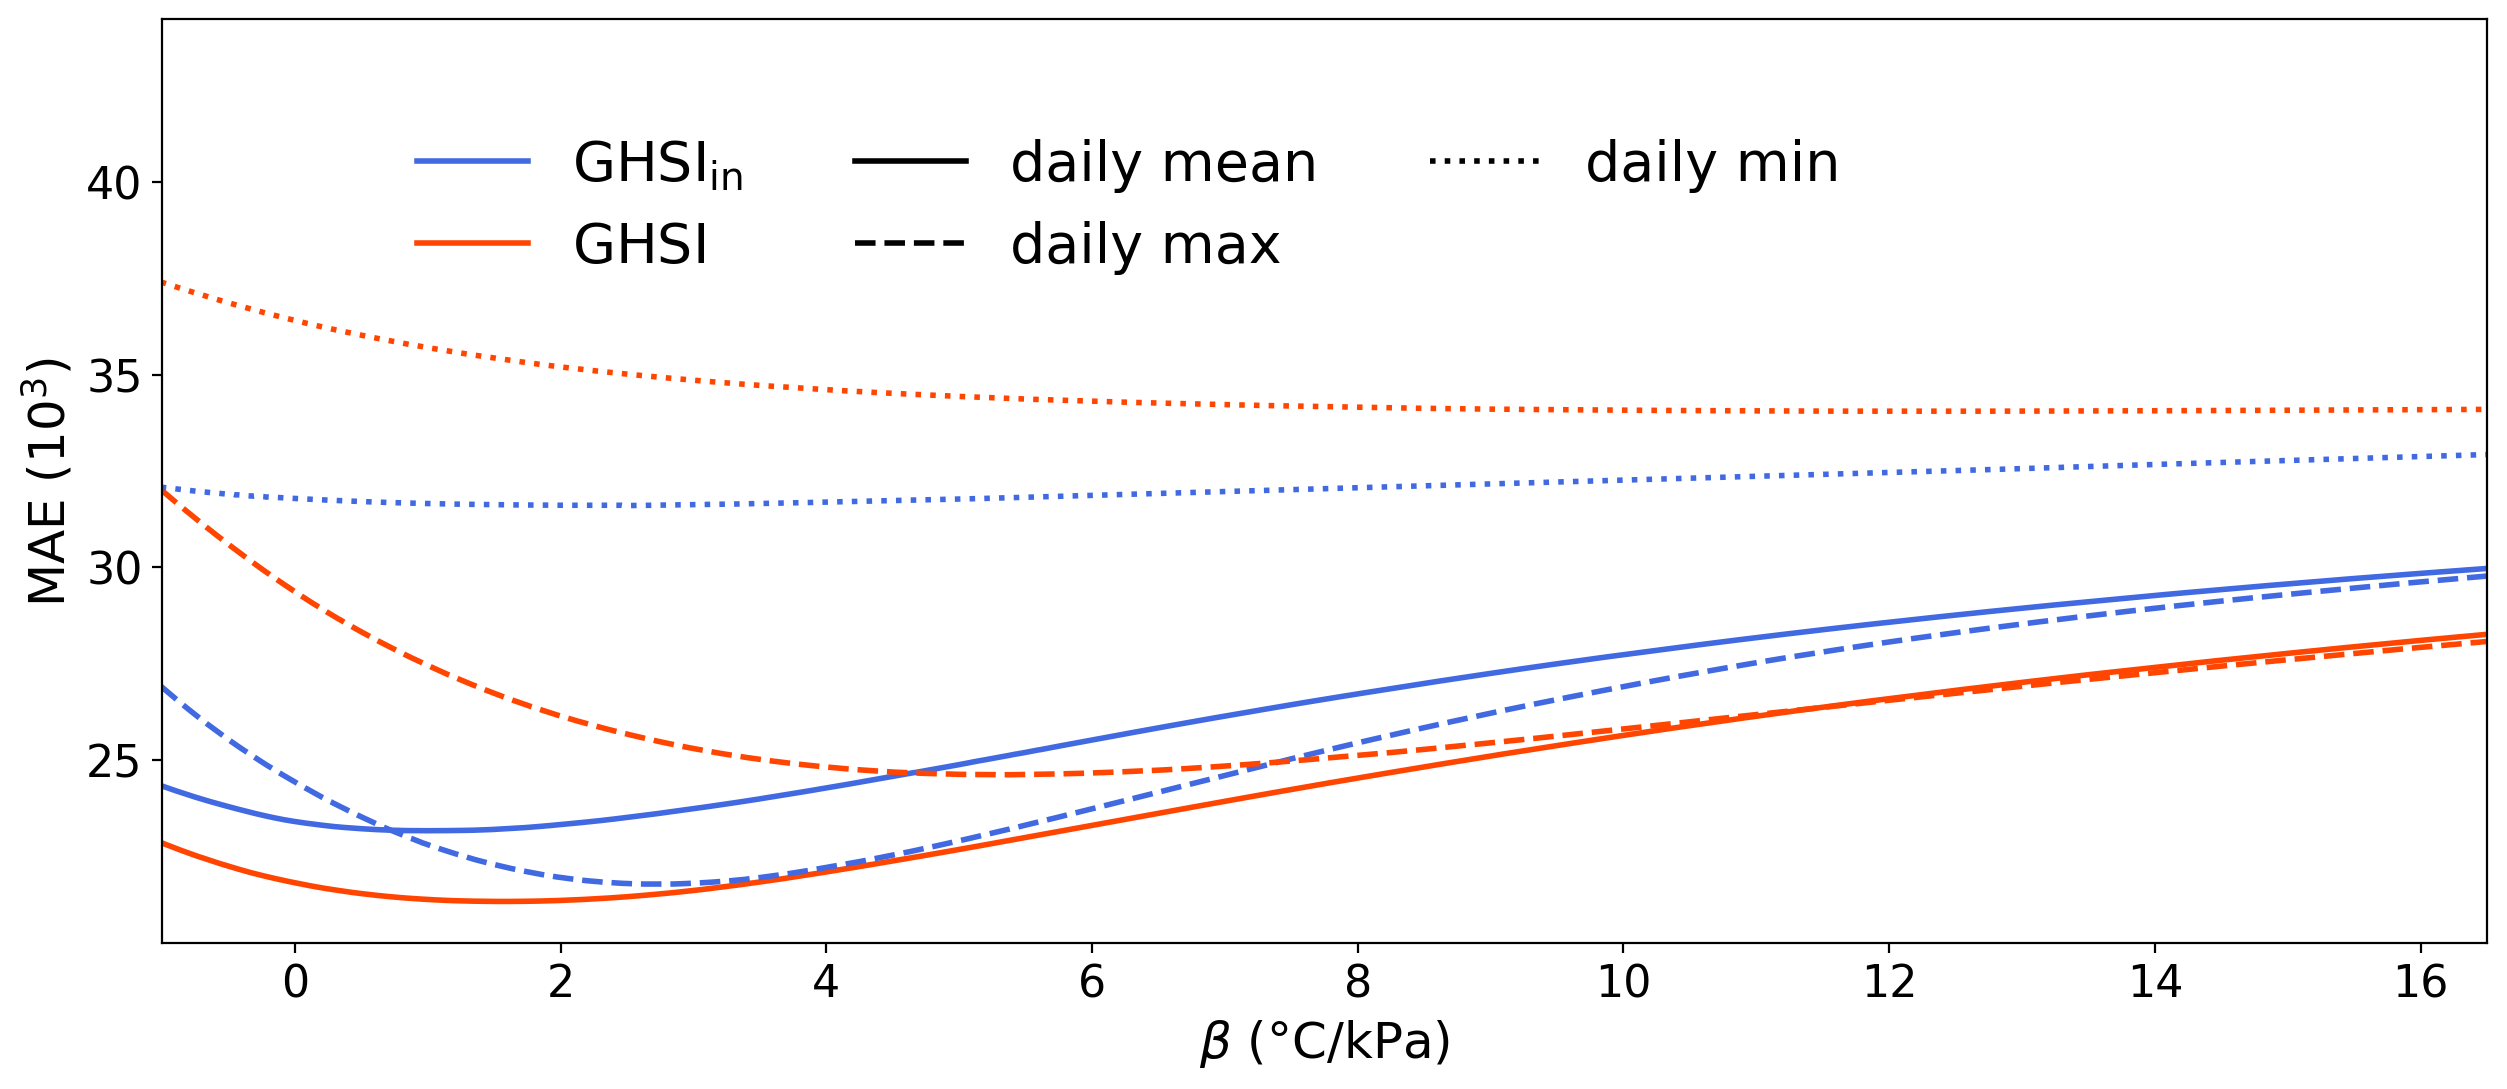

In [14]:
# create figure
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(1,1,1)  
X=mae.sel(exposure='indoor').sum('pf').sel(beta=slice(-4,16.5))['beta'].values # X variable

# plot country total MAE of indoor GHSI across a wide range of beta values
ax.plot(X,mae.sel(exposure='indoor').sum('pf').sel(beta=slice(-4,16.5)),zorder=0,c='royalblue',linewidth=2)
ax.plot(X,mae.sel(exposure='outdoor').sum('pf').sel(beta=slice(-4,16.5)),zorder=0,c='orangered',linewidth=2)
ax.plot(X,mae_daily_max.sel(exposure='indoor').sum('pf').sel(beta=slice(-4,16.5)),zorder=0,c='royalblue',linewidth=2,linestyle='dashed')
ax.plot(X,mae_daily_max.sel(exposure='outdoor').sum('pf').sel(beta=slice(-4,16.5)),zorder=0,c='orangered',linewidth=2,linestyle='dashed')


ax.plot(X,mae_daily_min.sel(exposure='indoor').sum('pf').sel(beta=slice(-4,16.5)),zorder=0,c='royalblue',linewidth=2,linestyle='dotted')
ax.plot(X,mae_daily_min.sel(exposure='outdoor').sum('pf').sel(beta=slice(-4,16.5)),zorder=0,c='orangered',linewidth=2,linestyle='dotted')


# legend: color for GHSI vs GHSIin, linewidth for lag
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='royalblue', linewidth=2, label=r'$\mathrm{GHSI}_{\mathrm{in}}$'),
    Line2D([0],[0], color='orangered', linewidth=2, label=r'$\mathrm{GHSI}$'),
    Line2D([0],[0], color='black', linewidth=2, label='daily mean',linestyle='solid'),
    Line2D([0],[0], color='black', linewidth=2, label='daily max',linestyle='dashed'),
    Line2D([0],[0], color='black', linewidth=2, label='daily min',linestyle='dotted'),
]
ax.legend(handles=legend_elements, fontsize=20, frameon=False, loc=(0.1,0.7),ncol=3)

ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(-1,16.5)
ax.set_ylabel('MAE '+ '('+r'$\mathrm{10}^{\mathrm{3}}$'+')',fontsize=18)
ax.set_xlabel(r'$\beta$ (°C/kPa)',fontsize=18)
#ax.set_ylim(20,32)

**Fig. A5.** National total summer cumulative MAE for the outdoor and indoor formulations of GHSI as a function of $\beta$, calibrated using daily mean (solid), maximum (dashed), and minimum (dotted) values.